In [1]:
import pandas as pd
import numpy as np

# =====================================================
# DATA VISUALIZATION LIBRARIES
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# PREPROCESSING LIBRARIES
# =====================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# =====================================================
# DATA SPLITTING
# =====================================================

from sklearn.model_selection import train_test_split

# =====================================================
# REGRESSION MODELS
# =====================================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# =====================================================
# EVALUATION METRICS
# =====================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("C:\\Users\\User\\Downloads\\archive (4).zip")

In [16]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [17]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [18]:
df.shape

(200, 4)

In [19]:
df.size

800

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [21]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [22]:
for col in df.columns:
    
    if df[col].nunique() <= 10:
        
        print(f"\nColumn: {col}")
        print(df[col].unique())

In [ ]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [24]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


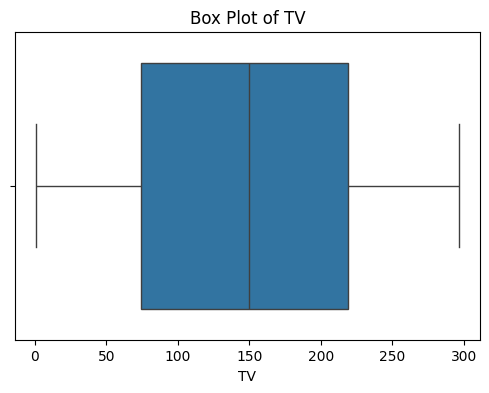

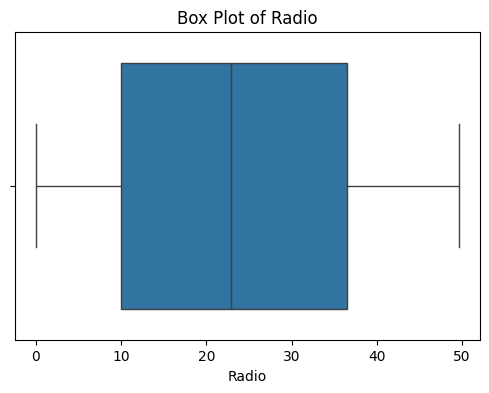

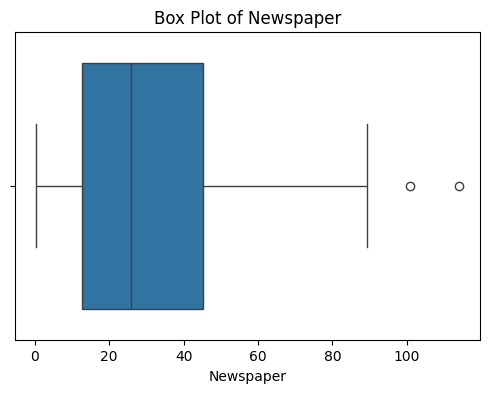

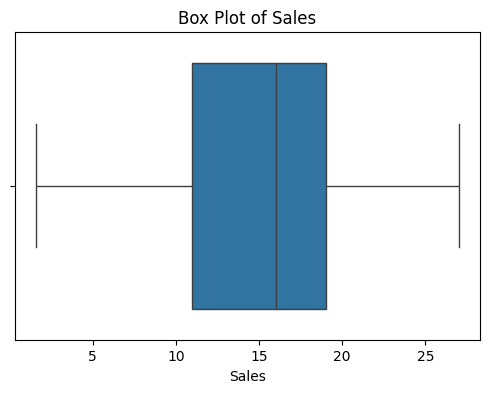

In [25]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Box Plot of {col}")

    plt.show()

In [26]:
Q1 = df["Newspaper"].quantile(0.25)
Q3 = df["Newspaper"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Newspaper"] >= lower) &
        (df["Newspaper"] <= upper)]

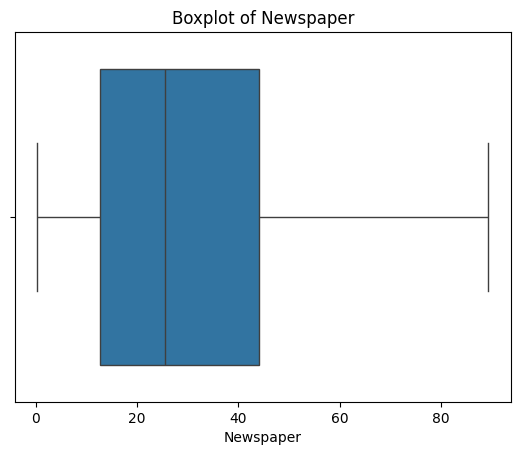

In [27]:
sns.boxplot(x=df["Newspaper"])
plt.title("Boxplot of Newspaper")
plt.show()

In [28]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
corr

,TV,Radio,Newspaper,Sales
TV,1.000000,0.051978,0.049771,0.899974
Radio,0.051978,1.000000,0.346364,0.348566
Newspaper,0.049771,0.346364,1.000000,0.151764
Sales,0.899974,0.348566,0.151764,1.000000


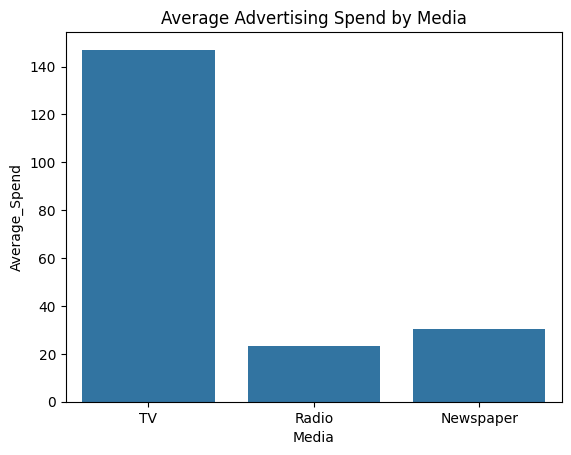

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

avg_spend = pd.DataFrame({
    "Media": ["TV", "Radio", "Newspaper"],
    "Average_Spend": [
        df["TV"].mean(),
        df["Radio"].mean(),
        df["Newspaper"].mean()
    ]
})

sns.barplot(x="Media", y="Average_Spend", data=avg_spend)
plt.title("Average Advertising Spend by Media")
plt.show()

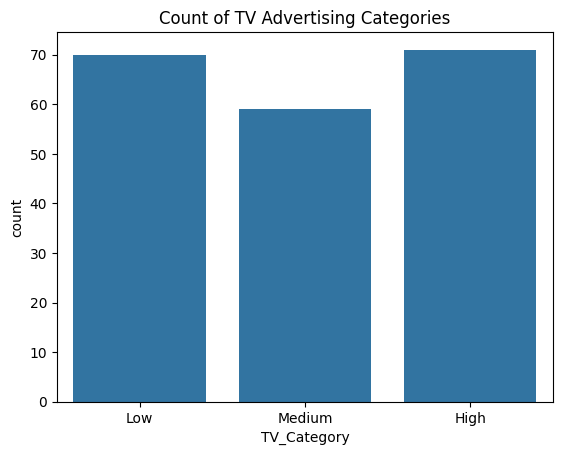

In [6]:
df["TV_Category"] = pd.cut(
    df["TV"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

sns.countplot(x="TV_Category", data=df)
plt.title("Count of TV Advertising Categories")
plt.show()

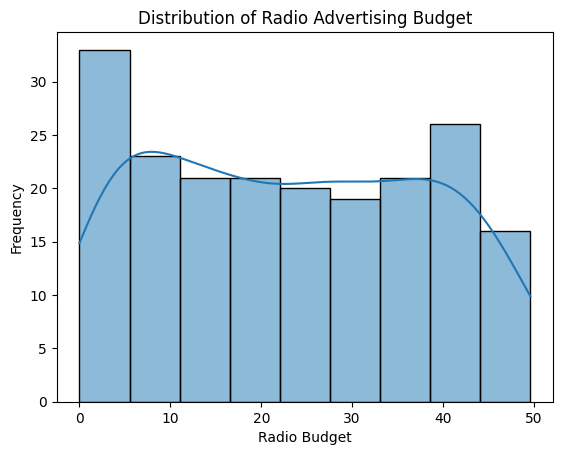

In [7]:
sns.histplot(df["Radio"], kde=True)
plt.title("Distribution of Radio Advertising Budget")
plt.xlabel("Radio Budget")
plt.ylabel("Frequency")
plt.show()

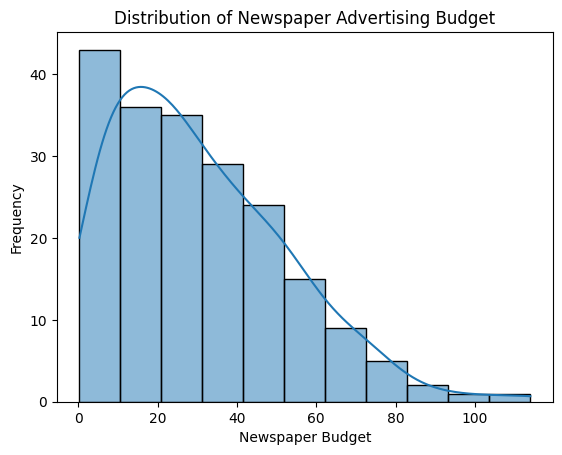

In [8]:
sns.histplot(df["Newspaper"], kde=True)
plt.title("Distribution of Newspaper Advertising Budget")
plt.xlabel("Newspaper Budget")
plt.ylabel("Frequency")
plt.show()

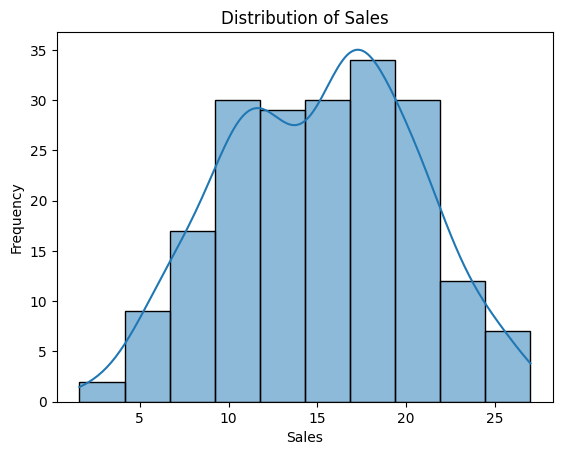

In [9]:
sns.histplot(df["Sales"], kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

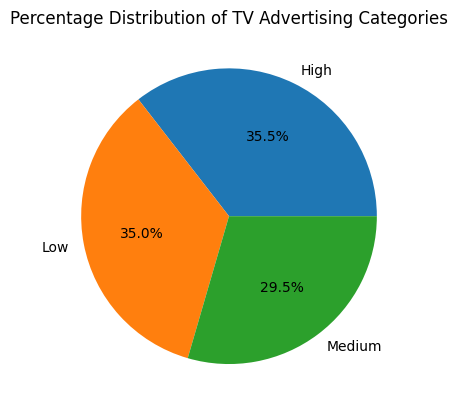

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df["TV_Category"] = pd.cut(
    df["TV"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

df["TV_Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Percentage Distribution of TV Advertising Categories")
plt.ylabel("")
plt.show()

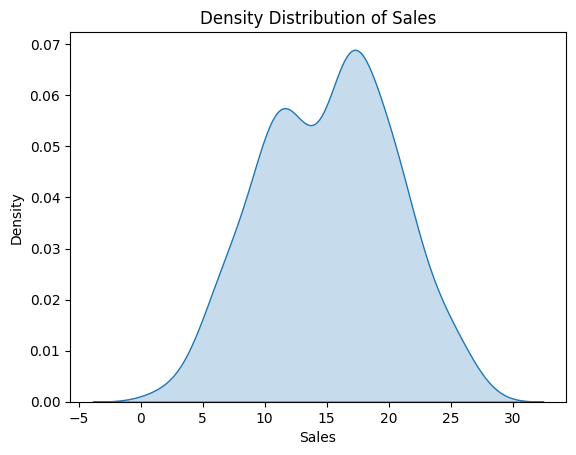

In [11]:
sns.kdeplot(df["Sales"], fill=True)
plt.title("Density Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.show()

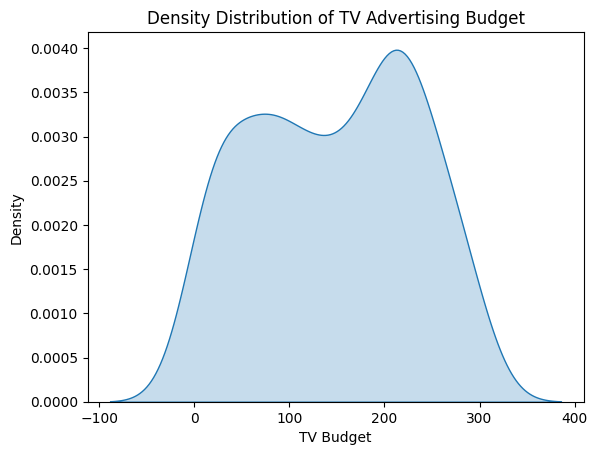

In [12]:
sns.kdeplot(df["TV"], fill=True)
plt.title("Density Distribution of TV Advertising Budget")
plt.xlabel("TV Budget")
plt.ylabel("Density")
plt.show()

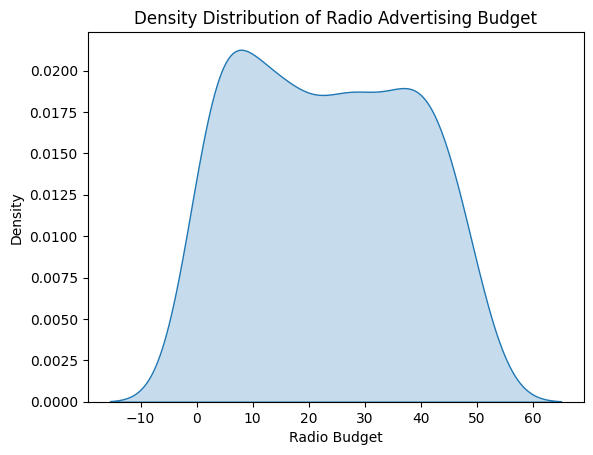

In [13]:
sns.kdeplot(df["Radio"], fill=True)
plt.title("Density Distribution of Radio Advertising Budget")
plt.xlabel("Radio Budget")
plt.ylabel("Density")
plt.show()

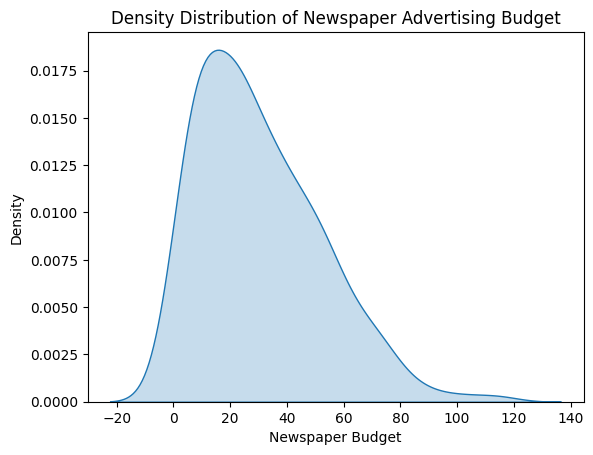

In [14]:
sns.kdeplot(df["Newspaper"], fill=True)
plt.title("Density Distribution of Newspaper Advertising Budget")
plt.xlabel("Newspaper Budget")
plt.ylabel("Density")
plt.show()

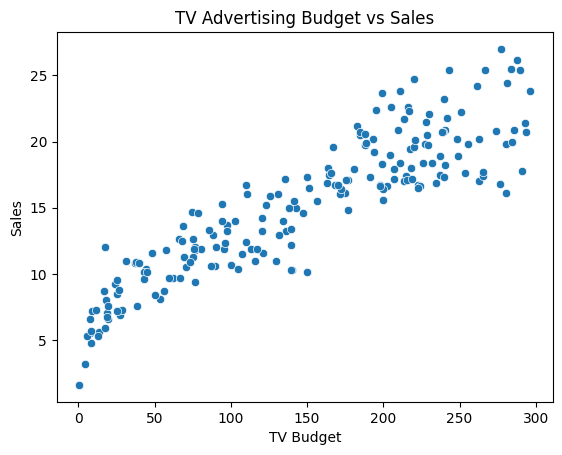

In [15]:
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("TV Advertising Budget vs Sales")
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.show()

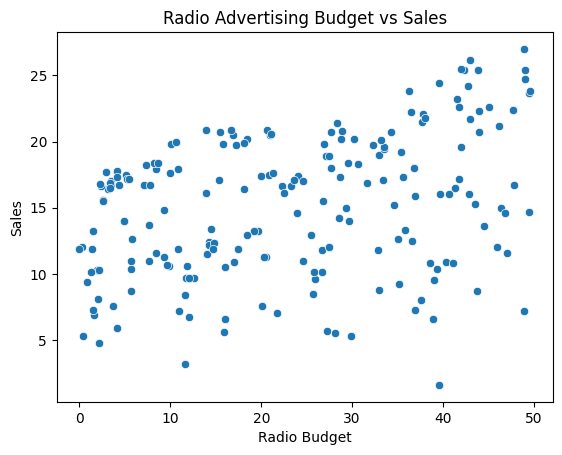

In [16]:
sns.scatterplot(x="Radio", y="Sales", data=df)
plt.title("Radio Advertising Budget vs Sales")
plt.xlabel("Radio Budget")
plt.ylabel("Sales")
plt.show()

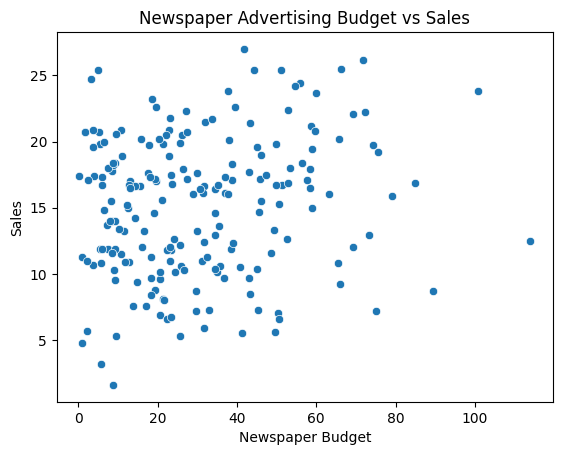

In [17]:
sns.scatterplot(x="Newspaper", y="Sales", data=df)
plt.title("Newspaper Advertising Budget vs Sales")
plt.xlabel("Newspaper Budget")
plt.ylabel("Sales")
plt.show()

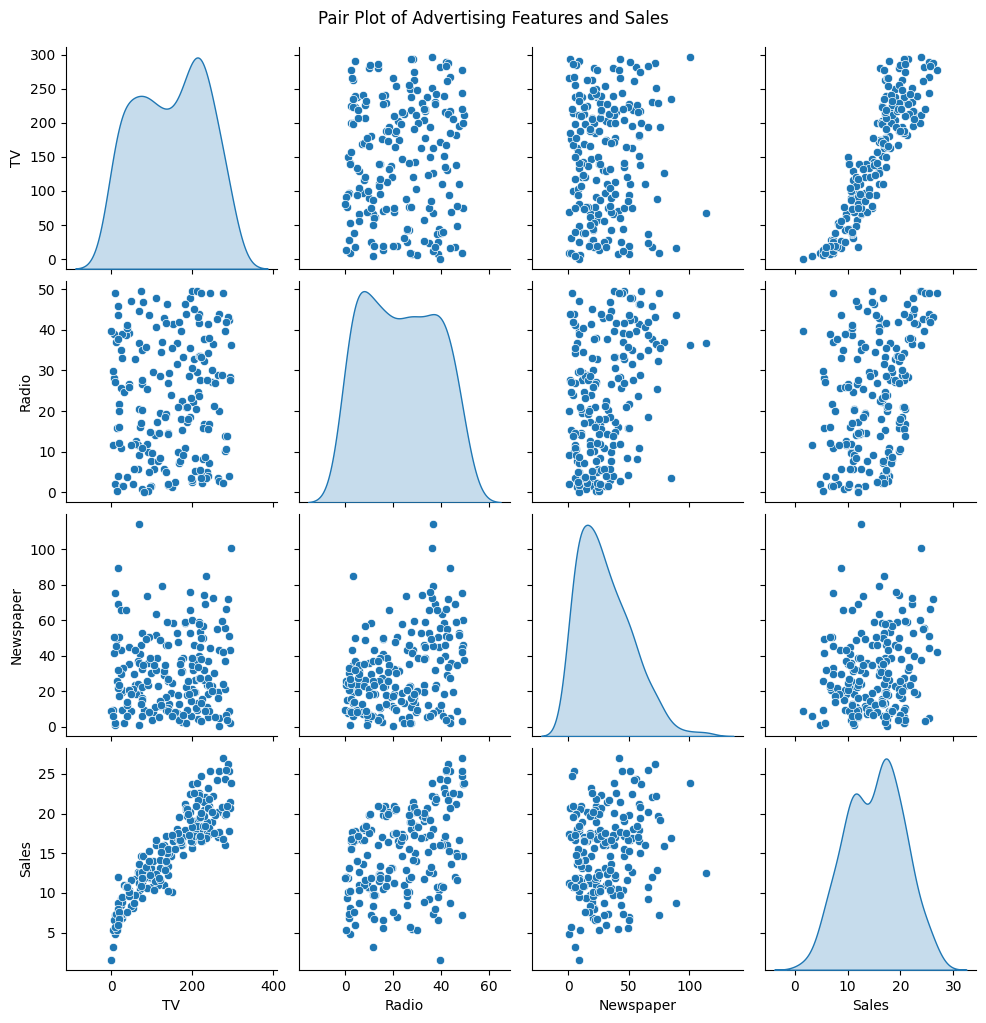

In [18]:
sns.pairplot(
    df[["TV", "Radio", "Newspaper", "Sales"]],
    diag_kind="kde"
)
plt.suptitle("Pair Plot of Advertising Features and Sales", y=1.02)
plt.show()

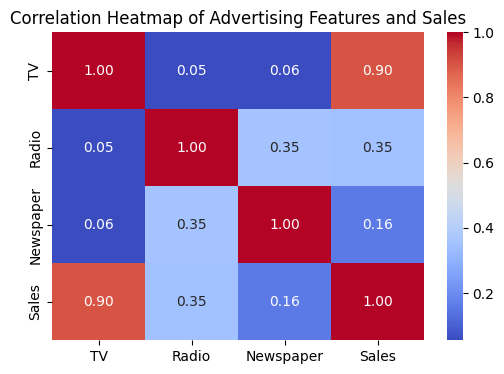

In [24]:


plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Advertising Features and Sales")
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Sales", axis=1)
y = df["Sales"]

scaler = StandardScaler()
X = pd.get_dummies(df.drop("Sales", axis=1), columns=["TV_Category"], drop_first=True)
y = df["Sales"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("R^2 Score :", r2_score(y_test, lr_pred))

R^2 Score : 0.897970240101561


In [30]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("R^2 Score :", r2_score(y_test, dt_pred))

R^2 Score : 0.9139270123070052


In [31]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("R^2 Score :", r2_score(y_test, dt_pred))

R^2 Score : 0.9139270123070052


In [32]:
print("Linear Regression :", r2_score(y_test, lr_pred))
print("Decision Tree :", r2_score(y_test, dt_pred))
print("Random Forest :",r2_score(y_test, rf_pred))


Linear Regression : 0.897970240101561
Decision Tree : 0.9139270123070052
Random Forest : 0.9521265642647025


In [33]:
print("MAE :",mean_absolute_error(y_test,lr_pred))
print("MSE :",mean_squared_error(y_test,lr_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,lr_pred)))

MAE : 1.3017347017616365
MSE : 3.152831813597653
RMSE : 1.775621528816784


In [35]:
new_ad = pd.DataFrame({
    "TV": [150],
    "Radio": [25],
    "Newspaper": [20],
    "TV_Category_Medium": [False],
    "TV_Category_High": [False]
})

model = rf  # or use lr / dt if you want linear regression or decision tree

predicted_sales = model.predict(new_ad)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 14.925999999999993
